# Figure 5 Generative Model Grid Search

Cache-first notebook for fitting the HD-MEA differentiation simulation to empirical active-site structure. The primary diagnostic is a **2D spatial KS statistic** between the empirical selected-electrode layout imprint and the simulated survivor layout imprint. Lower KS values indicate a better match.

Two model families are screened:

- **Axonal-only:** near-field exponential + axonal exponential. Grid axes: near-field relative amplitude and axonal decay length.
- **Ephaptic-axonal:** near-field exponential + gamma-modulated ephaptic interference term. Grid axes: near-field relative amplitude and interference frequency.

The notebook stores only derived result rows and figure summaries under `outputs/figure5_generative_model_grid_search/`. It does not store simulated coordinate clouds or empirical input tables in the figure cache. Synchrony is not used here; this figure fits the spatial active-electrode imprint only.

In [200]:
from dataclasses import asdict, replace
import hashlib
import json
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if not (repo_root / "ephax").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from ephax.modeling import HDMEADifferentiationConfig, build_kernel_curves, make_hd_mea_grid, run_apoptosis_simulation
from ephax.plotting import PAPER_COLORS, apply_paper_style, compose_figure, export_figure, figure, group, panel

apply_paper_style()

{'font.family': ['DejaVu Sans'],
 'font.size': 5.5,
 'axes.titlesize': 6,
 'axes.labelsize': 5.5,
 'xtick.labelsize': 5.0,
 'ytick.labelsize': 5.0,
 'legend.fontsize': 5.0,
 'axes.labelpad': 1.0,
 'axes.titlepad': 2.0,
 'axes.linewidth': 0.4,
 'xtick.major.width': 0.4,
 'ytick.major.width': 0.4,
 'xtick.minor.width': 0.4,
 'ytick.minor.width': 0.4,
 'xtick.major.size': 1.2,
 'ytick.major.size': 1.2,
 'xtick.minor.size': 0.8,
 'ytick.minor.size': 0.8,
 'xtick.major.pad': 0.5,
 'ytick.major.pad': 0.5,
 'xtick.minor.pad': 0.5,
 'ytick.minor.pad': 0.5,
 'lines.linewidth': 0.4,
 'axes.grid': False,
 'figure.dpi': 160,
 'pdf.fonttype': 42,
 'ps.fonttype': 42,
 'svg.fonttype': 'none',
 'savefig.dpi': 450,
 'axes.prop_cycle': cycler('color', ['#40bfff', '#807fff', '#2ca02c', '#1f77b4', '#8c8c8c', '#E69F00', '#56B4E9', '#000000'])}

## Configuration

In [201]:
DATASET = "stim_removal_null"
AGGREGATE_WELLS = [0, 1, 2, 3, 4, 5]
AGGREGATE_DIVS = [12, 14, 21, 22, 23, 26]
TARGET_DIV = max(AGGREGATE_DIVS)
EMPIRICAL_TOP_N = 100

# Use a physically matched downsampled lattice for fast grid search. Set to "confirm" for 220 x 120.
GRID_SEARCH_PROFILE = "screen"  # "screen" or "confirm"
GRID_SEARCH_FORCE_RECOMPUTE = False
GRID_SEARCH_RUN = True
GRID_REPLICATES = 5
RANDOM_SEED = 0

# Statistical model-comparison controls. These are result-only cached tables.
STAT_BOOTSTRAP_REPS = 1000
STAT_SHUFFLE_REPS = 1000
STAT_SIMULATION_SEEDS = 20
STAT_FORCE_RECOMPUTE = False
STAT_RUN_SIMULATION_SEED_STABILITY = True

# Shared simulation settings.
SIMULATION_PLATING_LOSS_FRACTION = 0.70
SIMULATION_TARGET_FRACTION = 0.40
SIMULATION_SUBSAMPLE_SIZE = 20
NEAR_FIELD_DECAY_UM = 100.0
LAMBDA_EPH_UM = 1_000_000.0
V_EPH_M_S = 0.0833
V_AX_M_S = 0.60

# Grid axes. Keep these modest for first-pass screens; increase for confirmatory reruns.
NEAR_FIELD_RELATIVE_AMPLITUDE_GRID = np.array([um for um in np.logspace(0, 2, 10)])
AXONAL_DECAY_GRID_UM = np.array([um for um in np.logspace(2, 4, 10)])
EPHAPTIC_FREQUENCY_GRID_HZ = np.array([hz for hz in np.linspace(30.0, 70.0, 15)])

OUTPUT_DIR = repo_root / "outputs" / "figure5_generative_model_grid_search"
TABLE_DIR = OUTPUT_DIR / "tables"
SAVE_FIGURE = True

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

## Helpers

In [202]:
def profile_grid_config(profile: str):
    if profile == "screen":
        return 110, 60, 35.0
    if profile == "confirm":
        return 220, 120, 17.5
    raise ValueError(f"Unknown GRID_SEARCH_PROFILE={profile!r}")


def base_simulation_config(**overrides):
    cols, rows, pitch = profile_grid_config(GRID_SEARCH_PROFILE)
    cfg = HDMEADifferentiationConfig(
        grid_columns=cols,
        grid_rows=rows,
        pitch_um=pitch,
        # The base frequency is inert for axonal-only candidates and overridden for ephaptic-axonal candidates.
        hz=float(HDMEADifferentiationConfig().hz),
        v_eph_m_s=float(V_EPH_M_S),
        v_ax_m_s=float(V_AX_M_S),
        lambda_eph_um=float(LAMBDA_EPH_UM),
        # This base value is overridden for axonal-only candidates; ephaptic-axonal candidates do not use axonal_decay_um.
        axonal_decay_um=float(HDMEADifferentiationConfig().axonal_decay_um),
        near_field_decay_um=float(NEAR_FIELD_DECAY_UM),
        near_field_relative_amplitude=3.0,
        subsample_size=int(SIMULATION_SUBSAMPLE_SIZE),
        random_seed=int(RANDOM_SEED),
        plating_loss_fraction=float(SIMULATION_PLATING_LOSS_FRACTION),
        target_fraction=float(SIMULATION_TARGET_FRACTION),
        milestone_step_fraction=0.20,
    )
    return replace(cfg, **overrides)


def config_digest():
    payload = {
        "dataset": DATASET,
        "wells": list(map(int, AGGREGATE_WELLS)),
        "divs": list(map(int, AGGREGATE_DIVS)),
        "target_div": int(TARGET_DIV),
        "empirical_top_n": int(EMPIRICAL_TOP_N),
        "profile": GRID_SEARCH_PROFILE,
        "replicates": int(GRID_REPLICATES),
        "random_seed": int(RANDOM_SEED),
        "base_config": asdict(base_simulation_config()),
        "near_grid": np.asarray(NEAR_FIELD_RELATIVE_AMPLITUDE_GRID, float).round(8).tolist(),
        "axonal_decay_grid_um": np.asarray(AXONAL_DECAY_GRID_UM, float).round(8).tolist(),
        "ephaptic_frequency_grid_hz": np.asarray(EPHAPTIC_FREQUENCY_GRID_HZ, float).round(8).tolist(),
    }
    return hashlib.sha1(json.dumps(payload, sort_keys=True).encode("utf-8")).hexdigest()[:12]

CONFIG_DIGEST = config_digest()
STAT_DIGEST = hashlib.sha1(
    json.dumps(
        {
            "config_digest": CONFIG_DIGEST,
            "bootstrap_reps": int(STAT_BOOTSTRAP_REPS),
            "shuffle_reps": int(STAT_SHUFFLE_REPS),
            "simulation_seeds": int(STAT_SIMULATION_SEEDS),
            "run_simulation_seed_stability": bool(STAT_RUN_SIMULATION_SEED_STABILITY),
            "stat_method": "recording_bootstrap_spatial_shuffle_seed_stability_v2",
        },
        sort_keys=True,
    ).encode("utf-8")
).hexdigest()[:12]
GRID_RESULT_PATH = TABLE_DIR / f"grid_search_results_{CONFIG_DIGEST}.csv"
GRID_SUMMARY_PATH = TABLE_DIR / f"grid_search_summary_{CONFIG_DIGEST}.csv"
METHODS_PATH = TABLE_DIR / f"figure5_methods_{CONFIG_DIGEST}.csv"
RESULTS_PATH = TABLE_DIR / f"figure5_results_{CONFIG_DIGEST}.csv"
STAT_BOOTSTRAP_PATH = TABLE_DIR / f"model_comparison_recording_bootstrap_{STAT_DIGEST}.csv"
STAT_SHUFFLE_PATH = TABLE_DIR / f"model_comparison_spatial_label_shuffle_{STAT_DIGEST}.csv"
STAT_SIM_SEED_PATH = TABLE_DIR / f"model_comparison_simulation_seed_stability_{STAT_DIGEST}.csv"
STAT_SUMMARY_PATH = TABLE_DIR / f"figure5_model_comparison_stats_{STAT_DIGEST}.csv"

In [203]:
def load_selected_electrode_targets():
    path = repo_root / "outputs" / "figure4_activity_distance" / "tables" / "selected_electrode_coords.csv.gz"
    if not path.exists():
        raise FileNotFoundError(
            "Missing selected-electrode coordinate table from Figure 4. "
            "Run the Figure 4 selected-electrode table build once, or point this notebook to an equivalent table."
        )
    df = pd.read_csv(path)
    required = {"dataset", "well", "div", "recording_id", "electrode", "selected_rank", "x_um", "y_um"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Selected-electrode table is missing columns: {sorted(missing)}")
    df = df.loc[df["dataset"].astype(str) == DATASET].copy()
    df = df.loc[df["well"].astype(int).isin([int(w) for w in AGGREGATE_WELLS])].copy()
    available_divs = sorted(df["div"].astype(int).unique().tolist())
    if int(TARGET_DIV) not in available_divs:
        resolved = max(available_divs)
        print(f"TARGET_DIV={TARGET_DIV} not present in selected-electrode table; using latest available DIV {resolved}.")
    else:
        resolved = int(TARGET_DIV)
    target = df.loc[df["div"].astype(int) == resolved].copy()
    target = target.loc[pd.to_numeric(target["selected_rank"], errors="coerce") <= int(EMPIRICAL_TOP_N)].copy()
    if target.empty:
        raise ValueError("No empirical selected electrodes remain after TARGET_DIV / EMPIRICAL_TOP_N filtering.")
    target["resolved_target_div"] = resolved
    return target


def occupancy_grid_from_coords(coords_um: np.ndarray, config: HDMEADifferentiationConfig):
    coords = np.asarray(coords_um, dtype=float)
    counts = np.zeros((int(config.grid_rows), int(config.grid_columns)), dtype=float)
    if coords.size == 0:
        return counts
    col = np.rint(coords[:, 0] / float(config.pitch_um)).astype(int)
    row = np.rint(coords[:, 1] / float(config.pitch_um)).astype(int)
    keep = (row >= 0) & (row < config.grid_rows) & (col >= 0) & (col < config.grid_columns)
    np.add.at(counts, (row[keep], col[keep]), 1.0)
    return counts


def spatial_ks_2d_from_counts(observed_counts: np.ndarray, simulated_counts: np.ndarray):
    observed = np.asarray(observed_counts, dtype=float)
    simulated = np.asarray(simulated_counts, dtype=float)
    if observed.shape != simulated.shape:
        raise ValueError(f"Occupancy grids must have identical shape, got {observed.shape} and {simulated.shape}")
    obs_total = float(np.nansum(observed))
    sim_total = float(np.nansum(simulated))
    if obs_total <= 0 or sim_total <= 0:
        return np.nan
    obs_cdf = np.cumsum(np.cumsum(observed / obs_total, axis=0), axis=1)
    sim_cdf = np.cumsum(np.cumsum(simulated / sim_total, axis=0), axis=1)
    return float(np.nanmax(np.abs(obs_cdf - sim_cdf)))


def empirical_occupancy_grid(target_df: pd.DataFrame, config: HDMEADifferentiationConfig):
    return occupancy_grid_from_coords(target_df[["x_um", "y_um"]].to_numpy(float), config)

base_grid_config = base_simulation_config()
selected_target_df = load_selected_electrode_targets()
empirical_occupancy = empirical_occupancy_grid(selected_target_df, base_grid_config)
resolved_target_div = int(selected_target_df["resolved_target_div"].iloc[0])
print(
    f"Empirical target: DIV {resolved_target_div}, "
    f"{selected_target_df['recording_id'].nunique()} recordings, "
    f"{len(selected_target_df)} selected electrodes."
)

Empirical target: DIV 26, 6 recordings, 600 selected electrodes.


## Grid Search

In [204]:
def run_one_candidate(model: str, near_amp: float, axonal_decay_um, hz, replicate: int, target_occupancy: np.ndarray):
    cfg = base_simulation_config(
        near_field_relative_amplitude=float(near_amp),
        axonal_decay_um=float(axonal_decay_um if axonal_decay_um is not None else HDMEADifferentiationConfig().axonal_decay_um),
        hz=float(hz if hz is not None else HDMEADifferentiationConfig().hz),
        random_seed=int(RANDOM_SEED) + 10_000 * int(replicate) + (0 if model == "axonal_only" else 1_000),
    )
    grid = make_hd_mea_grid(cfg)
    result = run_apoptosis_simulation(
        grid,
        cfg,
        model_name=model,
        include_correlation=(model == "ephaptic_axonal"),
        show_progress=False,
    )
    sim_occupancy = occupancy_grid_from_coords(result["final_active"][["x_um", "y_um"]].to_numpy(float), cfg)
    ks_statistic = spatial_ks_2d_from_counts(target_occupancy, sim_occupancy)
    return {
        "model": model,
        "near_field_relative_amplitude": float(near_amp),
        "axonal_decay_um": np.nan if axonal_decay_um is None else float(axonal_decay_um),
        "hz": np.nan if hz is None else float(hz),
        "replicate": int(replicate),
        "ks_statistic": float(ks_statistic),
        "ks_pvalue": np.nan,
        "ks_kind": "2d_spatial_occupancy_cdf",
        "n_empirical_active_electrodes": int(np.nansum(target_occupancy)),
        "n_simulated_active_nodes": int(len(result["final_active"])),
        "final_active_nodes": int(len(result["final_active"])),
        "grid_columns": int(cfg.grid_columns),
        "grid_rows": int(cfg.grid_rows),
        "pitch_um": float(cfg.pitch_um),
        "target_div": int(resolved_target_div),
    }


def run_grid_search():
    rows = []
    started = time.time()
    for rep in range(int(GRID_REPLICATES)):
        for near_amp in NEAR_FIELD_RELATIVE_AMPLITUDE_GRID:
            for decay in AXONAL_DECAY_GRID_UM:
                rows.append(run_one_candidate("axonal_only", near_amp, decay, None, rep, empirical_occupancy))
            for hz in EPHAPTIC_FREQUENCY_GRID_HZ:
                rows.append(run_one_candidate("ephaptic_axonal", near_amp, None, hz, rep, empirical_occupancy))
        print(f"replicate {rep + 1}/{GRID_REPLICATES} complete after {(time.time() - started) / 60:.1f} min")
    return pd.DataFrame(rows)


def summarize_grid_results(results: pd.DataFrame):
    key_cols = ["model", "near_field_relative_amplitude", "axonal_decay_um", "hz", "target_div", "grid_columns", "grid_rows", "pitch_um", "ks_kind"]
    summary = (
        results.groupby(key_cols, dropna=False, as_index=False)
        .agg(
            ks_statistic_mean=("ks_statistic", "mean"),
            ks_statistic_median=("ks_statistic", "median"),
            ks_statistic_std=("ks_statistic", "std"),
            ks_pvalue_median=("ks_pvalue", "median"),
            n_replicates=("replicate", "nunique"),
            final_active_nodes=("final_active_nodes", "median"),
        )
    )
    return summary

if GRID_RESULT_PATH.exists() and GRID_SUMMARY_PATH.exists() and not GRID_SEARCH_FORCE_RECOMPUTE:
    grid_results = pd.read_csv(GRID_RESULT_PATH)
    grid_summary = pd.read_csv(GRID_SUMMARY_PATH)
    print(f"Loaded cached grid-search result rows from {GRID_RESULT_PATH}")
elif GRID_SEARCH_RUN:
    grid_results = run_grid_search()
    grid_summary = summarize_grid_results(grid_results)
    grid_results.to_csv(GRID_RESULT_PATH, index=False)
    grid_summary.to_csv(GRID_SUMMARY_PATH, index=False)
    print(f"Wrote grid-search summaries to {TABLE_DIR}")
else:
    grid_results = pd.DataFrame()
    grid_summary = pd.DataFrame()
    print("GRID_SEARCH_RUN=False and no compatible cache was loaded.")

grid_summary.head()

Loaded cached grid-search result rows from /Users/danielrebbin/Documents/GitHub/ephax/outputs/figure5_generative_model_grid_search/tables/grid_search_results_3d8be4c88137.csv


,model,near_field_relative_amplitude,axonal_decay_um,hz,target_div,grid_columns,grid_rows,pitch_um,ks_kind,ks_statistic_mean,ks_statistic_median,ks_statistic_std,ks_pvalue_median,n_replicates,final_active_nodes
0,axonal_only,1.0,100.000000,NaN,26,110,60,35.0,2d_spatial_occupancy_cdf,0.259017,0.257250,0.009653,NaN,5,792.0
1,axonal_only,1.0,166.810054,NaN,26,110,60,35.0,2d_spatial_occupancy_cdf,0.266025,0.262300,0.010456,NaN,5,792.0
2,axonal_only,1.0,278.255940,NaN,26,110,60,35.0,2d_spatial_occupancy_cdf,0.291263,0.290078,0.020354,NaN,5,792.0
3,axonal_only,1.0,464.158883,NaN,26,110,60,35.0,2d_spatial_occupancy_cdf,0.297130,0.301721,0.017903,NaN,5,792.0
4,axonal_only,1.0,774.263683,NaN,26,110,60,35.0,2d_spatial_occupancy_cdf,0.345247,0.345634,0.004609,NaN,5,792.0


In [205]:
def best_rows(summary: pd.DataFrame):
    if summary.empty:
        return pd.DataFrame()
    pieces = []
    for model, sub in summary.groupby("model", sort=True):
        idx = pd.to_numeric(sub["ks_statistic_mean"], errors="coerce").idxmin()
        pieces.append(sub.loc[[idx]].copy())
    return pd.concat(pieces, ignore_index=True) if pieces else pd.DataFrame()

best_grid_rows = best_rows(grid_summary)
best_grid_rows

,model,near_field_relative_amplitude,axonal_decay_um,hz,target_div,grid_columns,grid_rows,pitch_um,ks_kind,ks_statistic_mean,ks_statistic_median,ks_statistic_std,ks_pvalue_median,n_replicates,final_active_nodes
0,axonal_only,59.948425,166.810054,NaN,26,110,60,35.0,2d_spatial_occupancy_cdf,0.254160,0.245852,0.020900,NaN,5,792.0
1,ephaptic_axonal,7.742637,NaN,35.714286,26,110,60,35.0,2d_spatial_occupancy_cdf,0.181374,0.185374,0.011892,NaN,5,792.0


## Best-Fit Layout Imprints

For visualization only, rerun the best candidate from each model family once and place the simulated survivor layout next to the empirical active-electrode target. This does not change the grid-search cache; it only exposes the spatial imprint behind the best KS scores.

In [206]:
def matching_grid_result_rows(best_row: pd.Series):
    model = str(best_row["model"])
    rows = grid_results.loc[grid_results["model"] == model].copy()
    rows = rows.loc[np.isclose(rows["near_field_relative_amplitude"].astype(float), float(best_row["near_field_relative_amplitude"]))]
    if model == "axonal_only":
        rows = rows.loc[np.isclose(rows["axonal_decay_um"].astype(float), float(best_row["axonal_decay_um"]))]
    else:
        rows = rows.loc[np.isclose(rows["hz"].astype(float), float(best_row["hz"]))]
    return rows


def representative_grid_result_row(best_row: pd.Series):
    rows = matching_grid_result_rows(best_row)
    if rows.empty:
        return None
    target = float(best_row["ks_statistic_mean"])
    idx = (rows["ks_statistic"].astype(float) - target).abs().idxmin()
    return rows.loc[idx]


def run_best_layout_candidate(row: pd.Series):
    model = str(row["model"])
    representative = representative_grid_result_row(row)
    replicate = 0 if representative is None else int(representative["replicate"])
    cfg = base_simulation_config(
        near_field_relative_amplitude=float(row["near_field_relative_amplitude"]),
        axonal_decay_um=float(row["axonal_decay_um"]) if model == "axonal_only" else HDMEADifferentiationConfig().axonal_decay_um,
        hz=float(row["hz"]) if model == "ephaptic_axonal" else HDMEADifferentiationConfig().hz,
        random_seed=int(RANDOM_SEED) + 10_000 * int(replicate) + (0 if model == "axonal_only" else 1_000),
    )
    grid = make_hd_mea_grid(cfg)
    result = run_apoptosis_simulation(
        grid,
        cfg,
        model_name=f"best_{model}",
        include_correlation=(model == "ephaptic_axonal"),
        show_progress=False,
    )
    coords = result["final_active"][["x_um", "y_um"]].to_numpy(float)
    occupancy = occupancy_grid_from_coords(coords, cfg)
    layout_ks = spatial_ks_2d_from_counts(empirical_occupancy, occupancy)
    return {
        "model": model,
        "config": cfg,
        "coords_um": coords,
        "occupancy": occupancy,
        "ks_statistic": float(row["ks_statistic_mean"]),
        "layout_ks_statistic": float(layout_ks),
        "representative_replicate": int(replicate),
        "representative_replicate_ks": np.nan if representative is None else float(representative["ks_statistic"]),
        "row": row.to_dict(),
    }


def build_best_layout_data(best: pd.DataFrame):
    data = {
        "empirical": {
            "model": "empirical",
            "coords_um": selected_target_df[["x_um", "y_um"]].to_numpy(float),
            "occupancy": empirical_occupancy,
            "ks_statistic": 0.0,
            "config": base_grid_config,
        }
    }
    if best.empty:
        return data
    for _, row in best.iterrows():
        data[str(row["model"])] = run_best_layout_candidate(row)
    return data

best_layout_data = build_best_layout_data(best_grid_rows)
list(best_layout_data)

['empirical', 'axonal_only', 'ephaptic_axonal']

## Model-Comparison Statistics

These tests treat the grid-search result as a fitted model family comparison, not as an independent-sample KS p-value. They therefore use resampling over recordings and null spatial labels rather than reporting the nominal KS test p-value.

In [ ]:
def ks_against_best_models(occupancy):
    rows = []
    for model in ("axonal_only", "ephaptic_axonal"):
        if model not in best_layout_data:
            continue
        rows.append(
            {
                "model": model,
                "ks_statistic": spatial_ks_2d_from_counts(occupancy, best_layout_data[model]["occupancy"]),
            }
        )
    return pd.DataFrame(rows)


def best_grid_score_dict():
    out = {}
    if best_grid_rows.empty:
        return out
    for _, row in best_grid_rows.iterrows():
        out[str(row["model"])] = float(row["ks_statistic_mean"])
    return out


def observed_layout_score_dict():
    scored = ks_against_best_models(empirical_occupancy)
    if scored.empty:
        return {}
    return scored.set_index("model")["ks_statistic"].to_dict()


def paired_delta(scores):
    return float(scores.get("axonal_only", np.nan) - scores.get("ephaptic_axonal", np.nan))


def occupancy_from_recording_ids(recording_ids):
    pieces = []
    for recording_id in recording_ids:
        sub = selected_target_df.loc[selected_target_df["recording_id"] == recording_id, ["x_um", "y_um"]]
        if not sub.empty:
            pieces.append(sub)
    if not pieces:
        return np.zeros_like(empirical_occupancy)
    coords = pd.concat(pieces, ignore_index=True).to_numpy(float)
    return occupancy_grid_from_coords(coords, base_grid_config)


def build_recording_bootstrap_stats():
    recording_ids = np.asarray(sorted(selected_target_df["recording_id"].unique()), dtype=object)
    rng = np.random.default_rng(int(RANDOM_SEED) + 5100)
    rows = []
    for rep in range(int(STAT_BOOTSTRAP_REPS)):
        sampled = rng.choice(recording_ids, size=len(recording_ids), replace=True)
        occ = occupancy_from_recording_ids(sampled)
        scored = ks_against_best_models(occ)
        if scored.empty:
            continue
        values = scored.set_index("model")["ks_statistic"].to_dict()
        rows.append(
            {
                "replicate": rep,
                "n_recordings": len(recording_ids),
                "ks_axonal_only": values.get("axonal_only", np.nan),
                "ks_ephaptic_axonal": values.get("ephaptic_axonal", np.nan),
                "delta_ks_axonal_minus_ephaptic": paired_delta(values),
            }
        )
    return pd.DataFrame(rows)


def load_recorded_layout_table():
    path = repo_root / "outputs" / "figure4_activity_distance" / "tables" / "recorded_electrode_coords.csv.gz"
    if not path.exists():
        raise FileNotFoundError(f"Missing recorded electrode coordinate table: {path}")
    df = pd.read_csv(path)
    required = {"dataset", "well", "div", "recording_id", "electrode", "x_um", "y_um"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Recorded-coordinate table is missing columns: {sorted(missing)}")
    df = df.loc[df["dataset"].astype(str) == DATASET].copy()
    df = df.loc[df["well"].astype(int).isin([int(w) for w in AGGREGATE_WELLS])].copy()
    df = df.loc[df["div"].astype(int) == int(resolved_target_div)].copy()
    return df


def build_spatial_label_shuffle_stats():
    recorded = load_recorded_layout_table()
    selected_counts = selected_target_df.groupby("recording_id").size().to_dict()
    recorded_by_id = {rid: sub[["x_um", "y_um"]].to_numpy(float) for rid, sub in recorded.groupby("recording_id")}
    rng = np.random.default_rng(int(RANDOM_SEED) + 5200)
    rows = []
    recording_ids = sorted(selected_counts)
    for rep in range(int(STAT_SHUFFLE_REPS)):
        sampled_coords = []
        for rid in recording_ids:
            coords = recorded_by_id.get(rid)
            n = int(selected_counts[rid])
            if coords is None or len(coords) == 0 or n <= 0:
                continue
            idx = rng.choice(np.arange(len(coords)), size=n, replace=n > len(coords))
            sampled_coords.append(coords[idx])
        if not sampled_coords:
            continue
        occ = occupancy_grid_from_coords(np.vstack(sampled_coords), base_grid_config)
        scored = ks_against_best_models(occ)
        values = scored.set_index("model")["ks_statistic"].to_dict()
        rows.append(
            {
                "replicate": rep,
                "n_recordings": len(recording_ids),
                "ks_axonal_only": values.get("axonal_only", np.nan),
                "ks_ephaptic_axonal": values.get("ephaptic_axonal", np.nan),
                "delta_ks_axonal_minus_ephaptic": paired_delta(values),
            }
        )
    return pd.DataFrame(rows)


def run_best_candidate_seed(model, row, seed_offset):
    cfg = base_simulation_config(
        near_field_relative_amplitude=float(row["near_field_relative_amplitude"]),
        axonal_decay_um=float(row["axonal_decay_um"]) if model == "axonal_only" else HDMEADifferentiationConfig().axonal_decay_um,
        hz=float(row["hz"]) if model == "ephaptic_axonal" else HDMEADifferentiationConfig().hz,
        random_seed=int(RANDOM_SEED) + int(seed_offset) + (0 if model == "axonal_only" else 1_000),
    )
    grid = make_hd_mea_grid(cfg)
    result = run_apoptosis_simulation(
        grid,
        cfg,
        model_name=f"seed_{model}",
        include_correlation=(model == "ephaptic_axonal"),
        show_progress=False,
    )
    occ = occupancy_grid_from_coords(result["final_active"][["x_um", "y_um"]].to_numpy(float), cfg)
    return spatial_ks_2d_from_counts(empirical_occupancy, occ)


def build_simulation_seed_stability_stats():
    if best_grid_rows.empty or not STAT_RUN_SIMULATION_SEED_STABILITY:
        return pd.DataFrame()
    rows = []
    for _, row in best_grid_rows.iterrows():
        model = str(row["model"])
        for seed_idx in range(int(STAT_SIMULATION_SEEDS)):
            rows.append(
                {
                    "model": model,
                    "seed_idx": seed_idx,
                    "ks_statistic": run_best_candidate_seed(model, row, 100_000 + 7919 * seed_idx),
                }
            )
    return pd.DataFrame(rows)


def ci95(values):
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return np.nan, np.nan, np.nan
    return float(np.nanmedian(vals)), float(np.nanpercentile(vals, 2.5)), float(np.nanpercentile(vals, 97.5))


def permutation_pvalue(values, observed, *, alternative):
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0 or not np.isfinite(observed):
        return np.nan
    if alternative == "greater":
        return float((1 + np.sum(vals >= observed)) / (vals.size + 1))
    if alternative == "less":
        return float((1 + np.sum(vals <= observed)) / (vals.size + 1))
    if alternative == "two-sided":
        center = np.nanmedian(vals)
        return float((1 + np.sum(np.abs(vals - center) >= abs(observed - center))) / (vals.size + 1))
    raise ValueError(f"Unknown alternative={alternative!r}")


def summarize_model_comparison_stats(bootstrap_df, shuffle_df, seed_df):
    rows = []
    grid_scores = best_grid_score_dict()
    layout_scores = observed_layout_score_dict()
    grid_delta = paired_delta(grid_scores)
    layout_delta = paired_delta(layout_scores)
    n_recordings = int(selected_target_df["recording_id"].nunique())

    for model, ks_value in sorted(grid_scores.items()):
        rows.append(
            {
                "test": "grid_search_best_mean",
                "metric": "ks_statistic",
                "model": model,
                "estimate": ks_value,
                "ci_low": np.nan,
                "ci_high": np.nan,
                "null_median": np.nan,
                "p_value": np.nan,
                "df": int(max(GRID_REPLICATES - 1, 0)),
                "n": int(GRID_REPLICATES),
                "alternative": "descriptive_best_grid_mean",
                "note": "Mean KS across grid-search simulation replicates at the best parameter setting.",
            }
        )
    rows.append(
        {
            "test": "grid_search_best_mean",
            "metric": "delta_ks_axonal_minus_ephaptic",
            "model": "paired_models",
            "estimate": grid_delta,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "null_median": np.nan,
            "p_value": np.nan,
            "df": int(max(GRID_REPLICATES - 1, 0)),
            "n": int(GRID_REPLICATES),
            "alternative": "positive_delta_favors_ephaptic_axonal",
            "note": "Best axonal-only mean KS minus best ephaptic-axonal mean KS.",
        }
    )

    for model, ks_value in sorted(layout_scores.items()):
        rows.append(
            {
                "test": "observed_layout_score",
                "metric": "ks_statistic",
                "model": model,
                "estimate": ks_value,
                "ci_low": np.nan,
                "ci_high": np.nan,
                "null_median": np.nan,
                "p_value": np.nan,
                "df": int(max(n_recordings - 1, 0)),
                "n": n_recordings,
                "alternative": "descriptive_single_layout_score",
                "note": "KS between empirical selected-electrode occupancy and the representative best simulated layout.",
            }
        )

    if not bootstrap_df.empty:
        for col, model in [("ks_axonal_only", "axonal_only"), ("ks_ephaptic_axonal", "ephaptic_axonal"), ("delta_ks_axonal_minus_ephaptic", "paired_models")]:
            med, lo, hi = ci95(bootstrap_df[col])
            p_value = np.nan
            alternative = "recording_bootstrap_ci"
            if col == "delta_ks_axonal_minus_ephaptic":
                vals = pd.to_numeric(bootstrap_df[col], errors="coerce").to_numpy(float)
                p_value = float((1 + np.sum(vals <= 0)) / (np.sum(np.isfinite(vals)) + 1))
                alternative = "one_sided_delta_greater_than_zero"
            rows.append(
                {
                    "test": "recording_bootstrap",
                    "metric": col,
                    "model": model,
                    "estimate": med,
                    "ci_low": lo,
                    "ci_high": hi,
                    "null_median": np.nan,
                    "p_value": p_value,
                    "df": int(max(n_recordings - 1, 0)),
                    "n": int(bootstrap_df[col].notna().sum()),
                    "alternative": alternative,
                    "note": "Recording-level bootstrap over empirical selected-electrode layouts.",
                }
            )

    if not shuffle_df.empty:
        for col, model in [("ks_axonal_only", "axonal_only"), ("ks_ephaptic_axonal", "ephaptic_axonal"), ("delta_ks_axonal_minus_ephaptic", "paired_models")]:
            med, lo, hi = ci95(shuffle_df[col])
            observed = layout_scores.get(model, np.nan) if model != "paired_models" else layout_delta
            if model == "paired_models":
                p_value = permutation_pvalue(shuffle_df[col], observed, alternative="greater")
                alternative = "observed_delta_greater_than_location_shuffle"
            else:
                p_value = permutation_pvalue(shuffle_df[col], observed, alternative="less")
                alternative = "observed_ks_less_than_location_shuffle"
            rows.append(
                {
                    "test": "spatial_label_shuffle",
                    "metric": col,
                    "model": model,
                    "estimate": observed,
                    "ci_low": lo,
                    "ci_high": hi,
                    "null_median": med,
                    "p_value": p_value,
                    "df": int(max(n_recordings - 1, 0)),
                    "n": int(shuffle_df[col].notna().sum()),
                    "alternative": alternative,
                    "note": "Null randomly relabels selected electrodes within each recorded layout while preserving selected count per recording.",
                }
            )

    if seed_df is not None and not seed_df.empty:
        for model, sub in seed_df.groupby("model"):
            med, lo, hi = ci95(sub["ks_statistic"])
            rows.append(
                {
                    "test": "simulation_seed_stability",
                    "metric": "ks_statistic",
                    "model": model,
                    "estimate": med,
                    "ci_low": lo,
                    "ci_high": hi,
                    "null_median": np.nan,
                    "p_value": np.nan,
                    "df": int(max(sub["seed_idx"].nunique() - 1, 0)),
                    "n": int(sub["ks_statistic"].notna().sum()),
                    "alternative": "descriptive_simulation_stochasticity",
                    "note": "Best parameter setting rerun over additional simulation seeds.",
                }
            )
        pivot = seed_df.pivot_table(index="seed_idx", columns="model", values="ks_statistic", aggfunc="mean")
        if {"axonal_only", "ephaptic_axonal"}.issubset(pivot.columns):
            delta = pivot["axonal_only"].to_numpy(float) - pivot["ephaptic_axonal"].to_numpy(float)
            med, lo, hi = ci95(delta)
            vals = delta[np.isfinite(delta)]
            p_value = float((1 + np.sum(vals <= 0)) / (vals.size + 1)) if vals.size else np.nan
            rows.append(
                {
                    "test": "simulation_seed_stability",
                    "metric": "delta_ks_axonal_minus_ephaptic",
                    "model": "paired_models",
                    "estimate": med,
                    "ci_low": lo,
                    "ci_high": hi,
                    "null_median": np.nan,
                    "p_value": p_value,
                    "df": int(max(vals.size - 1, 0)),
                    "n": int(vals.size),
                    "alternative": "one_sided_delta_greater_than_zero",
                    "note": "Paired by simulation seed index across the two best parameter settings.",
                }
            )
    return pd.DataFrame(rows)


def load_or_build_stat_tables():
    paths = [STAT_BOOTSTRAP_PATH, STAT_SHUFFLE_PATH, STAT_SUMMARY_PATH]
    seed_path_needed = bool(STAT_RUN_SIMULATION_SEED_STABILITY)
    if seed_path_needed:
        paths.append(STAT_SIM_SEED_PATH)
    if all(path.exists() for path in paths) and not STAT_FORCE_RECOMPUTE:
        bootstrap_df = pd.read_csv(STAT_BOOTSTRAP_PATH)
        shuffle_df = pd.read_csv(STAT_SHUFFLE_PATH)
        seed_df = pd.read_csv(STAT_SIM_SEED_PATH) if STAT_SIM_SEED_PATH.exists() else pd.DataFrame()
        summary_df = pd.read_csv(STAT_SUMMARY_PATH)
        print(f"Loaded Figure 5 model-comparison statistics from {TABLE_DIR}")
        return bootstrap_df, shuffle_df, seed_df, summary_df
    bootstrap_df = build_recording_bootstrap_stats()
    shuffle_df = build_spatial_label_shuffle_stats()
    seed_df = build_simulation_seed_stability_stats()
    summary_df = summarize_model_comparison_stats(bootstrap_df, shuffle_df, seed_df)
    bootstrap_df.to_csv(STAT_BOOTSTRAP_PATH, index=False)
    shuffle_df.to_csv(STAT_SHUFFLE_PATH, index=False)
    if not seed_df.empty:
        seed_df.to_csv(STAT_SIM_SEED_PATH, index=False)
    summary_df.to_csv(STAT_SUMMARY_PATH, index=False)
    print(f"Wrote Figure 5 model-comparison statistics to {TABLE_DIR}")
    return bootstrap_df, shuffle_df, seed_df, summary_df

model_bootstrap_stats, model_shuffle_stats, model_seed_stats, model_stat_summary = load_or_build_stat_tables()
model_stat_summary

## Model-Comparison Statistical Diagnostics

In [ ]:
def draw_model_comparison_stat_diagnostics(axes):
    ax_boot, ax_shuffle, ax_seed = axes
    observed_layout_delta = paired_delta(observed_layout_score_dict())
    observed_grid_delta = paired_delta(best_grid_score_dict())

    if model_bootstrap_stats.empty:
        ax_boot.text(0.5, 0.5, "No bootstrap table", ha="center", va="center", transform=ax_boot.transAxes)
    else:
        vals = pd.to_numeric(model_bootstrap_stats["delta_ks_axonal_minus_ephaptic"], errors="coerce").dropna().to_numpy(float)
        ax_boot.hist(vals, bins=35, color=PAPER_COLORS.get("ephaptic_axonal", "0.4"), alpha=0.75)
        ax_boot.axvline(0, color="0.35", ls="--", lw=0.8)
        ax_boot.axvline(observed_layout_delta, color="black", lw=1.2, label="observed layout delta")
        ax_boot.axvline(observed_grid_delta, color="black", ls=":", lw=1.0, label="grid-mean delta")
        ax_boot.legend(frameon=False, loc="upper left")
    ax_boot.set_title("Recording-bootstrap model preference")
    ax_boot.set_xlabel("KS(axonal) - KS(ephaptic)")
    ax_boot.set_ylabel("bootstrap reps")

    if model_shuffle_stats.empty:
        ax_shuffle.text(0.5, 0.5, "No spatial-label shuffle table", ha="center", va="center", transform=ax_shuffle.transAxes)
    else:
        vals = pd.to_numeric(model_shuffle_stats["delta_ks_axonal_minus_ephaptic"], errors="coerce").dropna().to_numpy(float)
        ax_shuffle.hist(vals, bins=35, color="0.65", alpha=0.8, label="location-shuffle null")
        ax_shuffle.axvline(observed_layout_delta, color=PAPER_COLORS.get("ephaptic_axonal", "black"), lw=1.4, label="observed")
        ax_shuffle.axvline(0, color="0.35", ls="--", lw=0.8)
        ax_shuffle.legend(frameon=False, loc="upper left")
    ax_shuffle.set_title("Spatial-label shuffle null")
    ax_shuffle.set_xlabel("KS(axonal) - KS(ephaptic)")
    ax_shuffle.set_ylabel("null reps")

    if model_seed_stats.empty:
        ax_seed.text(0.5, 0.5, "Seed-stability disabled or missing", ha="center", va="center", transform=ax_seed.transAxes)
    else:
        order = [m for m in ["axonal_only", "ephaptic_axonal"] if m in set(model_seed_stats["model"])]
        data = [model_seed_stats.loc[model_seed_stats["model"] == model, "ks_statistic"].to_numpy(float) for model in order]
        ax_seed.boxplot(data, labels=[m.replace("_", "\n") for m in order], showfliers=False)
        for x, vals in enumerate(data, start=1):
            ax_seed.scatter(np.full(len(vals), x), vals, s=9, color="0.25", alpha=0.45, zorder=3)
    ax_seed.set_title("Best-parameter simulation-seed stability")
    ax_seed.set_ylabel("KS statistic")

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.2), constrained_layout=True)
draw_model_comparison_stat_diagnostics(axes)
plt.show()

## Figure Panels

In [207]:
def grid_ks_color_limits(summary: pd.DataFrame):
    if summary.empty or "ks_statistic_mean" not in summary:
        return None, None
    values = pd.to_numeric(summary["ks_statistic_mean"], errors="coerce").to_numpy(float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return None, None
    vmin = float(np.nanmin(values))
    vmax = float(np.nanmax(values))
    if np.isclose(vmin, vmax):
        pad = max(1e-6, 0.05 * abs(vmin))
        vmin -= pad
        vmax += pad
    return vmin, vmax


def draw_grid_heatmap(ax, summary: pd.DataFrame, *, model: str, vmin=None, vmax=None):
    if summary.empty:
        ax.text(0.5, 0.5, "No grid-search cache", ha="center", va="center", transform=ax.transAxes)
        return None
    sub = summary.loc[summary["model"] == model].copy()
    if sub.empty:
        ax.text(0.5, 0.5, f"No {model} rows", ha="center", va="center", transform=ax.transAxes)
        return None
    x_col = "axonal_decay_um" if model == "axonal_only" else "hz"
    pivot = sub.pivot_table(
        index="near_field_relative_amplitude",
        columns=x_col,
        values="ks_statistic_mean",
        aggfunc="mean",
    ).sort_index().sort_index(axis=1)
    x = pivot.columns.to_numpy(float)
    y = pivot.index.to_numpy(float)
    z = pivot.to_numpy(float)
    if vmin is None or vmax is None:
        vmin, vmax = grid_ks_color_limits(summary)
    mesh = ax.pcolormesh(x, y, z, shading="nearest", cmap="magma_r", vmin=vmin, vmax=vmax)
    best_idx = np.unravel_index(np.nanargmin(z), z.shape)
    ax.scatter([x[best_idx[1]]], [y[best_idx[0]]], marker="*", s=45, color="white", edgecolor="black", linewidth=0.4, zorder=5)
    best_value = z[best_idx]
    ax.text(
        0.03,
        0.97,
        f"best KS={best_value:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        color="white",
        bbox={"facecolor": "black", "alpha": 0.45, "edgecolor": "none", "pad": 2},
    )
    ax.set_ylabel("near-field relative amplitude")
    ax.set_yscale("log")
    if model == "axonal_only":
        ax.set_xlabel("axonal decay length (um)")
        ax.set_title("Axonal-only grid search")
        ax.set_xscale("log")
    else:
        ax.set_xlabel("interference frequency (Hz)")
        ax.set_title("Ephaptic-axonal grid search")
    return mesh


def draw_best_parameter_table(ax, best: pd.DataFrame):
    ax.axis("off")
    if best.empty:
        ax.text(0.0, 1.0, "No best-fit rows", va="top")
        return
    lines = [
        f"Target: DIV {resolved_target_div}, top {EMPIRICAL_TOP_N} active electrodes",
        f"Empirical recordings: {selected_target_df['recording_id'].nunique()}",
        f"Grid profile: {GRID_SEARCH_PROFILE}",
        "",
    ]
    for _, row in best.iterrows():
        if row["model"] == "axonal_only":
            param = f"decay={row['axonal_decay_um']:.0f} um"
        else:
            param = f"f={row['hz']:.1f} Hz"
        lines.append(
            f"{row['model']}: KS={row['ks_statistic_mean']:.3f}, "
            f"near={row['near_field_relative_amplitude']:.2f}, {param}"
        )
    ax.text(0.0, 1.0, "\n".join(lines), va="top", ha="left")


def draw_axonal_panel(data, ax, **options):
    vmin, vmax = grid_ks_color_limits(grid_summary)
    mesh = draw_grid_heatmap(ax, grid_summary, model="axonal_only", vmin=vmin, vmax=vmax)
    return {"mappable": mesh, "colorbar_label": "KS statistic"} if mesh is not None else None


def draw_ephaptic_panel(data, ax, **options):
    vmin, vmax = grid_ks_color_limits(grid_summary)
    mesh = draw_grid_heatmap(ax, grid_summary, model="ephaptic_axonal", vmin=vmin, vmax=vmax)
    return {"mappable": mesh, "colorbar_label": "KS statistic"} if mesh is not None else None



def layout_comparison_axes_factory(fig, subplotspec):
    gs = subplotspec.subgridspec(1, 3, wspace=0.18)
    return [fig.add_subplot(gs[0, i]) for i in range(3)]


def draw_layout_imprint(ax, coords_um: np.ndarray, title: str, color: str, *, ks_text=None):
    cfg = base_grid_config
    width_um = (int(cfg.grid_columns) - 1) * float(cfg.pitch_um)
    height_um = (int(cfg.grid_rows) - 1) * float(cfg.pitch_um)
    ax.set_facecolor("black")
    coords = np.asarray(coords_um, dtype=float)
    if coords.size:
        ax.scatter(coords[:, 0], coords[:, 1], s=4.5, c=color, alpha=0.75, linewidths=0)
    ax.set_xlim(0, width_um)
    ax.set_ylim(0, height_um)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("x (um)")
    ax.set_ylabel("y (um)")
    if ks_text is not None:
        ax.text(
            0.98,
            0.04,
            ks_text,
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            color="white",
            bbox={"facecolor": "black", "alpha": 0.55, "edgecolor": "none", "pad": 1.5},
        )


def draw_layout_comparison_panel(data, axes, **options):
    if not isinstance(axes, (list, tuple)) or len(axes) != 3:
        raise ValueError("draw_layout_comparison_panel expects three axes")
    layout_data = best_layout_data if data is None else data
    draw_layout_imprint(
        axes[0],
        layout_data["empirical"]["coords_um"],
        f"Empirical target\nDIV {resolved_target_div}, top {EMPIRICAL_TOP_N}",
        PAPER_COLORS.get("highlight", "#E69F00"),
        ks_text="target",
    )
    if "axonal_only" in layout_data:
        draw_layout_imprint(
            axes[1],
            layout_data["axonal_only"]["coords_um"],
            "Best axonal-only",
            PAPER_COLORS.get("axonal_only", "#40bfff"),
            ks_text=f"KS={layout_data['axonal_only']['ks_statistic']:.3f}",
        )
    else:
        axes[1].text(0.5, 0.5, "No axonal-only fit", ha="center", va="center", transform=axes[1].transAxes)
    if "ephaptic_axonal" in layout_data:
        draw_layout_imprint(
            axes[2],
            layout_data["ephaptic_axonal"]["coords_um"],
            "Best ephaptic-axonal",
            PAPER_COLORS.get("ephaptic_axonal", "#807fff"),
            ks_text=f"KS={layout_data['ephaptic_axonal']['ks_statistic']:.3f}",
        )
    else:
        axes[2].text(0.5, 0.5, "No ephaptic-axonal fit", ha="center", va="center", transform=axes[2].transAxes)



def config_from_best_row(row: pd.Series):
    model = str(row["model"])
    return base_simulation_config(
        near_field_relative_amplitude=float(row["near_field_relative_amplitude"]),
        axonal_decay_um=float(row["axonal_decay_um"]) if model == "axonal_only" else HDMEADifferentiationConfig().axonal_decay_um,
        hz=float(row["hz"]) if model == "ephaptic_axonal" else HDMEADifferentiationConfig().hz,
    )



def best_row_for_model(model: str):
    rows = best_grid_rows.loc[best_grid_rows["model"] == model]
    return None if rows.empty else rows.iloc[0]


def draw_single_best_kernel_panel(ax, model: str):
    row = best_row_for_model(model)
    if row is None:
        ax.text(0.5, 0.5, f"No {model} fit", ha="center", va="center", transform=ax.transAxes)
        return
    color = PAPER_COLORS.get("axonal_only" if model == "axonal_only" else "ephaptic_axonal", "0.2")
    cfg = config_from_best_row(row)
    grid = make_hd_mea_grid(cfg)
    curves = build_kernel_curves(grid, cfg, n_points=1200)
    r = curves["r_um"]
    if model == "axonal_only":
        ax.plot(r, curves["axonal"], color=color, lw=1.2, label="near-field + axonal exp")
        ax.plot(r, curves["near_field"], color=color, lw=0.75, ls=":", alpha=0.8, label="near-field")
        ax.plot(r, curves["axonal_component"], color=color, lw=0.75, ls="--", alpha=0.8, label="axonal exp")
        ax.set_title("Best axonal-only kernel")
        detail = f"decay={row['axonal_decay_um']:.0f} um, near={row['near_field_relative_amplitude']:.2f}"
    else:
        ax.plot(r, curves["ephaptic_axonal"], color=color, lw=1.2, label="near-field + interference")
        ax.plot(r, curves["near_field"], color=color, lw=0.75, ls=":", alpha=0.8, label="near-field")
        ax.plot(r, curves["ephaptic"], color=color, lw=0.75, ls="--", alpha=0.85, label="interference")
        ax.set_title("Best ephaptic-axonal kernel")
        detail = f"f={row['hz']:.1f} Hz, near={row['near_field_relative_amplitude']:.2f}"
    ax.axhline(0, color="0.55", lw=0.5)
    ax.text(0.02, 0.96, f"KS={row['ks_statistic_mean']:.3f}\n{detail}", transform=ax.transAxes, ha="left", va="top")
    ax.set_xlim(0, 3850)
    ax.set_xlabel("distance (um)")
    ax.set_ylabel("relative interaction score")
    ax.legend(frameon=False, loc="upper right")


def draw_axonal_kernel_panel(data, ax, **options):
    draw_single_best_kernel_panel(ax, "axonal_only")


def draw_ephaptic_kernel_panel(data, ax, **options):
    draw_single_best_kernel_panel(ax, "ephaptic_axonal")


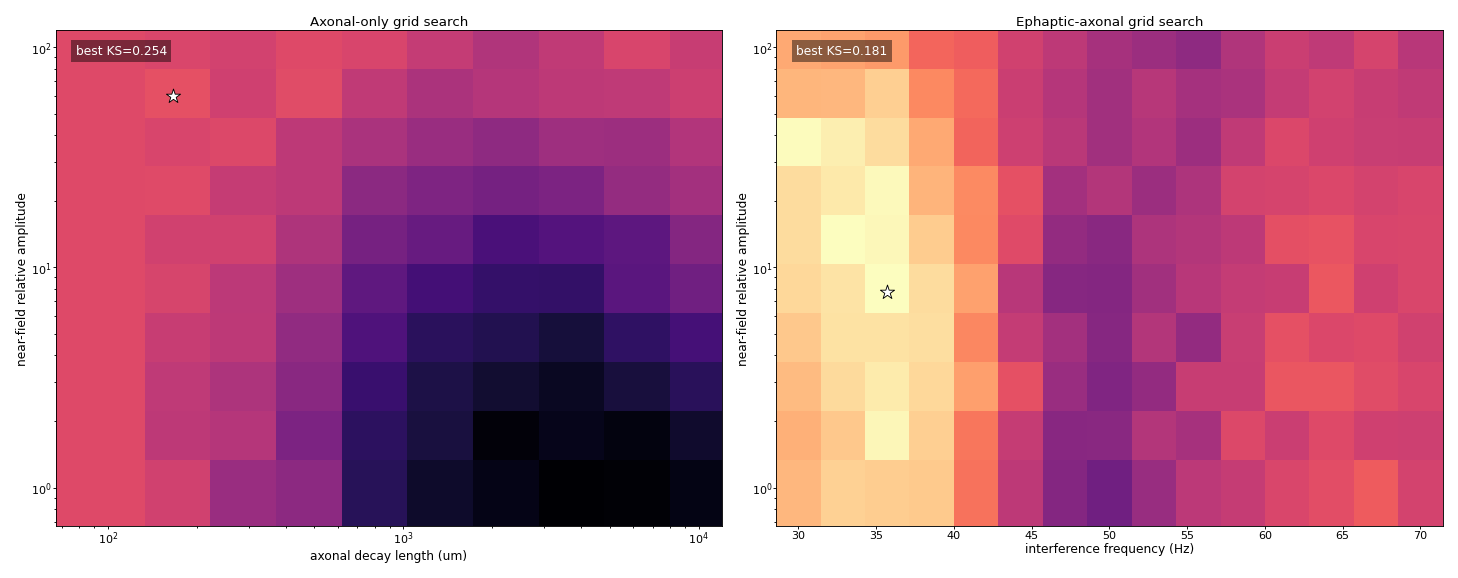

In [208]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.5), constrained_layout=True)
draw_grid_heatmap(axes[0], grid_summary, model="axonal_only")
draw_grid_heatmap(axes[1], grid_summary, model="ephaptic_axonal")
plt.show()

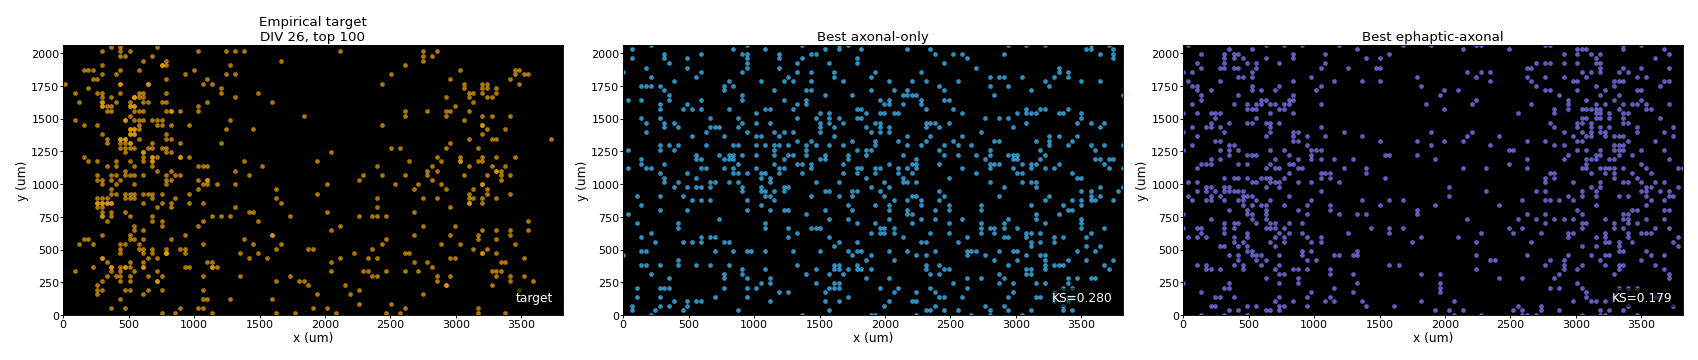

In [209]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 2.8), constrained_layout=True)
draw_layout_comparison_panel(best_layout_data, list(axes))
plt.show()

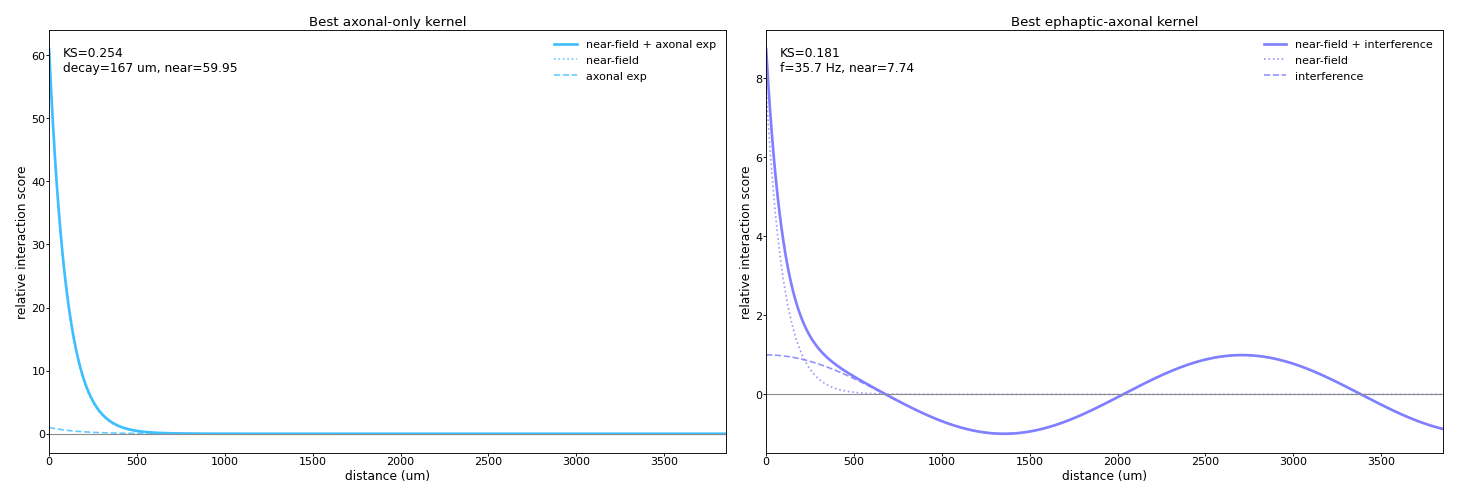

In [210]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.0), constrained_layout=True)
draw_axonal_kernel_panel(None, axes[0])
draw_ephaptic_kernel_panel(None, axes[1])
plt.show()

## Composed Figure 5

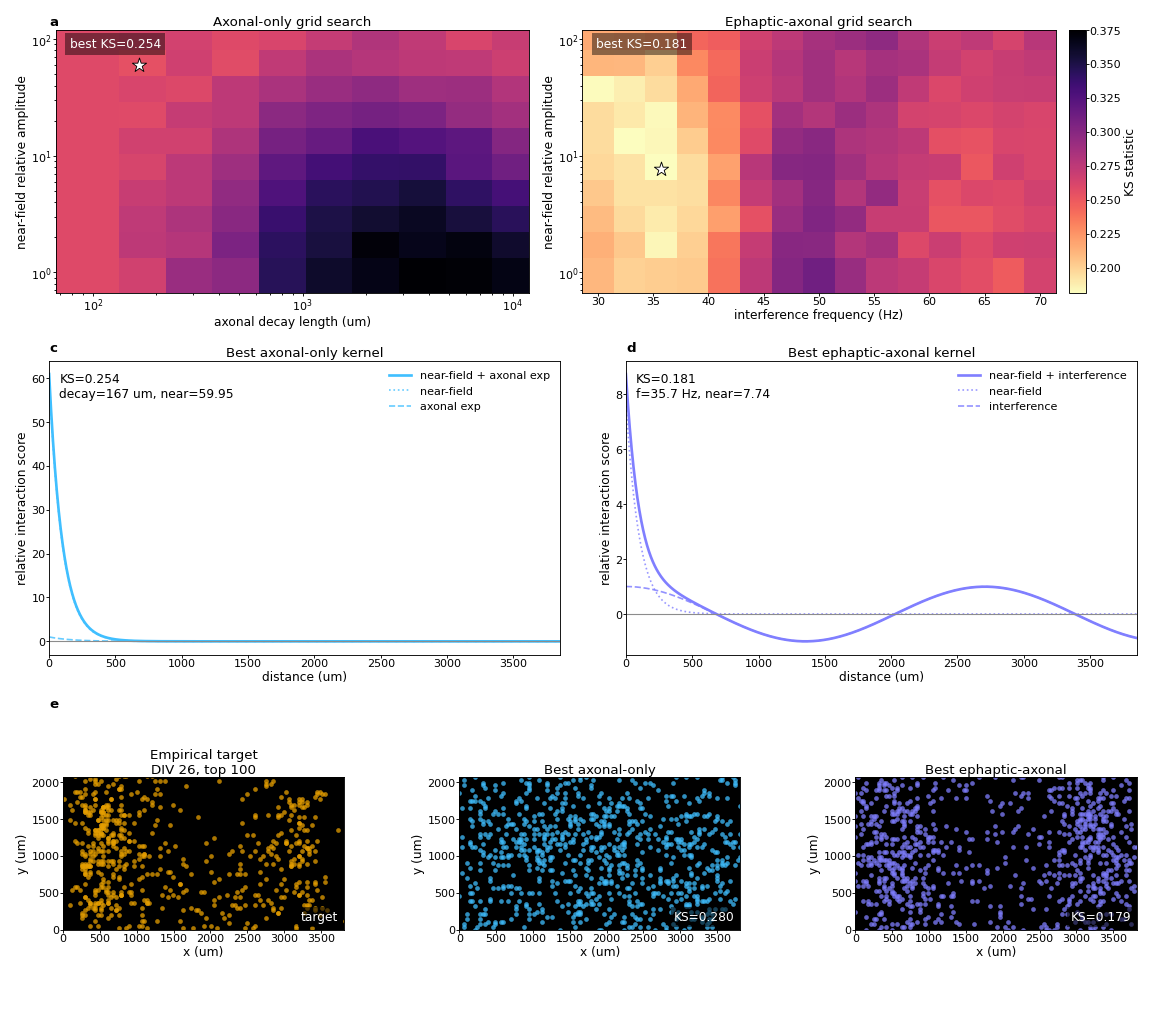

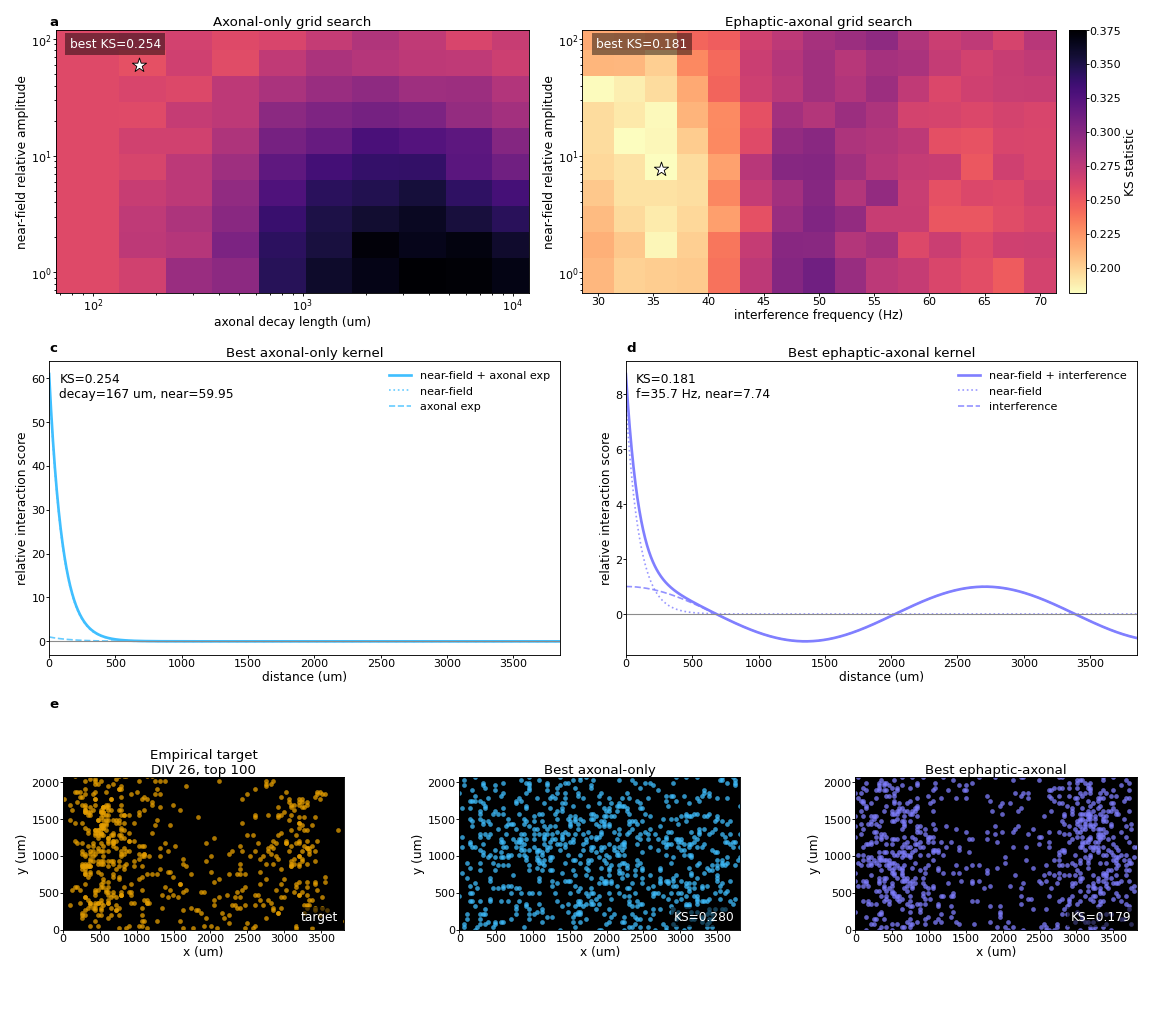

In [211]:
fig5 = compose_figure(
    figure(width="two_column", height=160, ncols=12),
    [
        group(
            "a",
            label="a",
            loc=(0, 0, 1, 12),
            ncols=2,
            shared_colorbar=True,
            children=[
                panel("a_axonal", draw=draw_axonal_panel),
                panel("a_ephaptic", draw=draw_ephaptic_panel),
            ],
        ),
        panel("c", label="c", loc=(1, 0, 1, 6), draw=draw_axonal_kernel_panel),
        panel("d", label="d", loc=(1, 6, 1, 6), draw=draw_ephaptic_kernel_panel),
        panel(
            "e",
            label="e",
            loc=(2, 0, 1, 12),
            draw=draw_layout_comparison_panel,
            data=best_layout_data,
            axes_factory=layout_comparison_axes_factory,
        ),
    ],
)
fig5.fig

In [212]:
def write_report_tables():
    methods = pd.DataFrame([
        {"parameter": "DATASET", "value": DATASET, "note": "Empirical selected-electrode source dataset."},
        {"parameter": "TARGET_DIV", "value": resolved_target_div, "note": "DIV used as empirical target for KS fitting."},
        {"parameter": "EMPIRICAL_TOP_N", "value": EMPIRICAL_TOP_N, "note": "Top active electrodes per recording used for empirical 2D occupancy imprint."},
        {"parameter": "GRID_SEARCH_PROFILE", "value": GRID_SEARCH_PROFILE, "note": "screen uses a downsampled physical HD-MEA grid; confirm uses full density."},
        {"parameter": "SIMULATION_PLATING_LOSS_FRACTION", "value": SIMULATION_PLATING_LOSS_FRACTION, "note": "Randomly removed fraction before activity-dependent pruning."},
        {"parameter": "SIMULATION_TARGET_FRACTION", "value": SIMULATION_TARGET_FRACTION, "note": "Target survivor fraction after pruning."},
        {"parameter": "NEAR_FIELD_DECAY_UM", "value": NEAR_FIELD_DECAY_UM, "note": "Fixed decay length of immediate near-field term."},
        {"parameter": "GRID_REPLICATES", "value": GRID_REPLICATES, "note": "Independent simulation repeats per grid candidate."},
        {"parameter": "STAT_BOOTSTRAP_REPS", "value": STAT_BOOTSTRAP_REPS, "note": "Recording-level bootstrap replicates for paired delta-KS model comparison."},
        {"parameter": "STAT_SHUFFLE_REPS", "value": STAT_SHUFFLE_REPS, "note": "Spatial-label shuffle null replicates preserving selected-electrode count per recording."},
        {"parameter": "STAT_SIMULATION_SEEDS", "value": STAT_SIMULATION_SEEDS, "note": "Additional stochastic simulation seeds for best-candidate stability."},
    ])
    results = best_grid_rows.copy()
    if "model_stat_summary" in globals() and not model_stat_summary.empty:
        model_stat_summary.to_csv(TABLE_DIR / f"figure5_model_comparison_stats_latest.csv", index=False)
    methods.to_csv(METHODS_PATH, index=False)
    results.to_csv(RESULTS_PATH, index=False)
    return methods, results

figure5_methods, figure5_results = write_report_tables()
if SAVE_FIGURE:
    export_figure(fig5.fig, OUTPUT_DIR / "figure5_generative_model_grid_search", formats=("pdf", "svg", "png"))
    print(f"Saved Figure 5 draft and report tables to {OUTPUT_DIR}")
figure5_results

Saved Figure 5 draft and report tables to /Users/danielrebbin/Documents/GitHub/ephax/outputs/figure5_generative_model_grid_search


,model,near_field_relative_amplitude,axonal_decay_um,hz,target_div,grid_columns,grid_rows,pitch_um,ks_kind,ks_statistic_mean,ks_statistic_median,ks_statistic_std,ks_pvalue_median,n_replicates,final_active_nodes
0,axonal_only,59.948425,166.810054,NaN,26,110,60,35.0,2d_spatial_occupancy_cdf,0.254160,0.245852,0.020900,NaN,5,792.0
1,ephaptic_axonal,7.742637,NaN,35.714286,26,110,60,35.0,2d_spatial_occupancy_cdf,0.181374,0.185374,0.011892,NaN,5,792.0
